In [76]:
import numpy as np
import matplotlib.pyplot as plt

In [95]:
#vars 
N = 512
N_fft =64
pi = np.pi
f1 = 50.23
f2 = 16

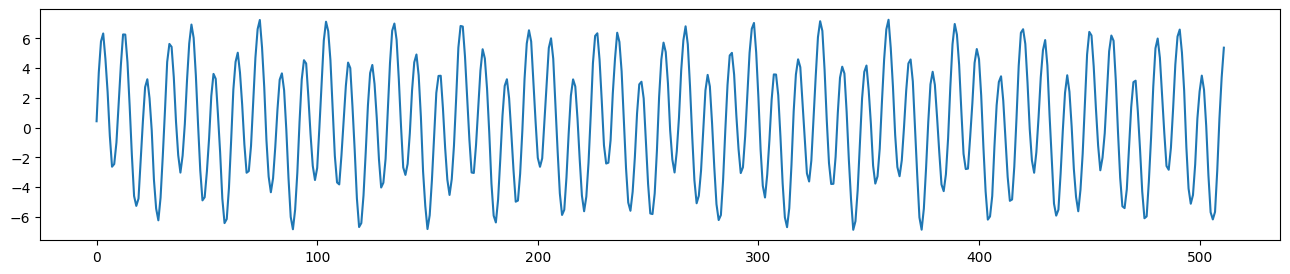

In [96]:
t = np.linspace(0, 2*pi, num=N)
x =  0.5*np.random.random(N) + 5*np.sin(f1*t) + 2*np.sin(f2*t)

fig, ax = plt.subplots()
fig.set_size_inches(16,3)
ax.plot(x)
plt.show()

In [97]:
fft_win = np.kaiser(N_fft,0)
fft_x = abs(np.fft.fft(x, N_fft)*fft_win)**2

In [101]:
#lms constants  
p = N_fft #AR order
mu = 1e-4#Adaptive step size
rho = 0.5 #variance of noise
T =N

In [102]:
def ar_est_lms(mu, p ,x):
    ap = np.zeros(p)
    xp = np.ones(p)
    for i in range(len(x)):
        ef = x[i] + xp.T @ ap #calculate filter residual
        ap = ap - 2*mu*ef*xp.conj() #update AR coefficient vector
        xp[1:] = xp[:p-1]   #update data vector
        xp[0] = x[i]
    return ap

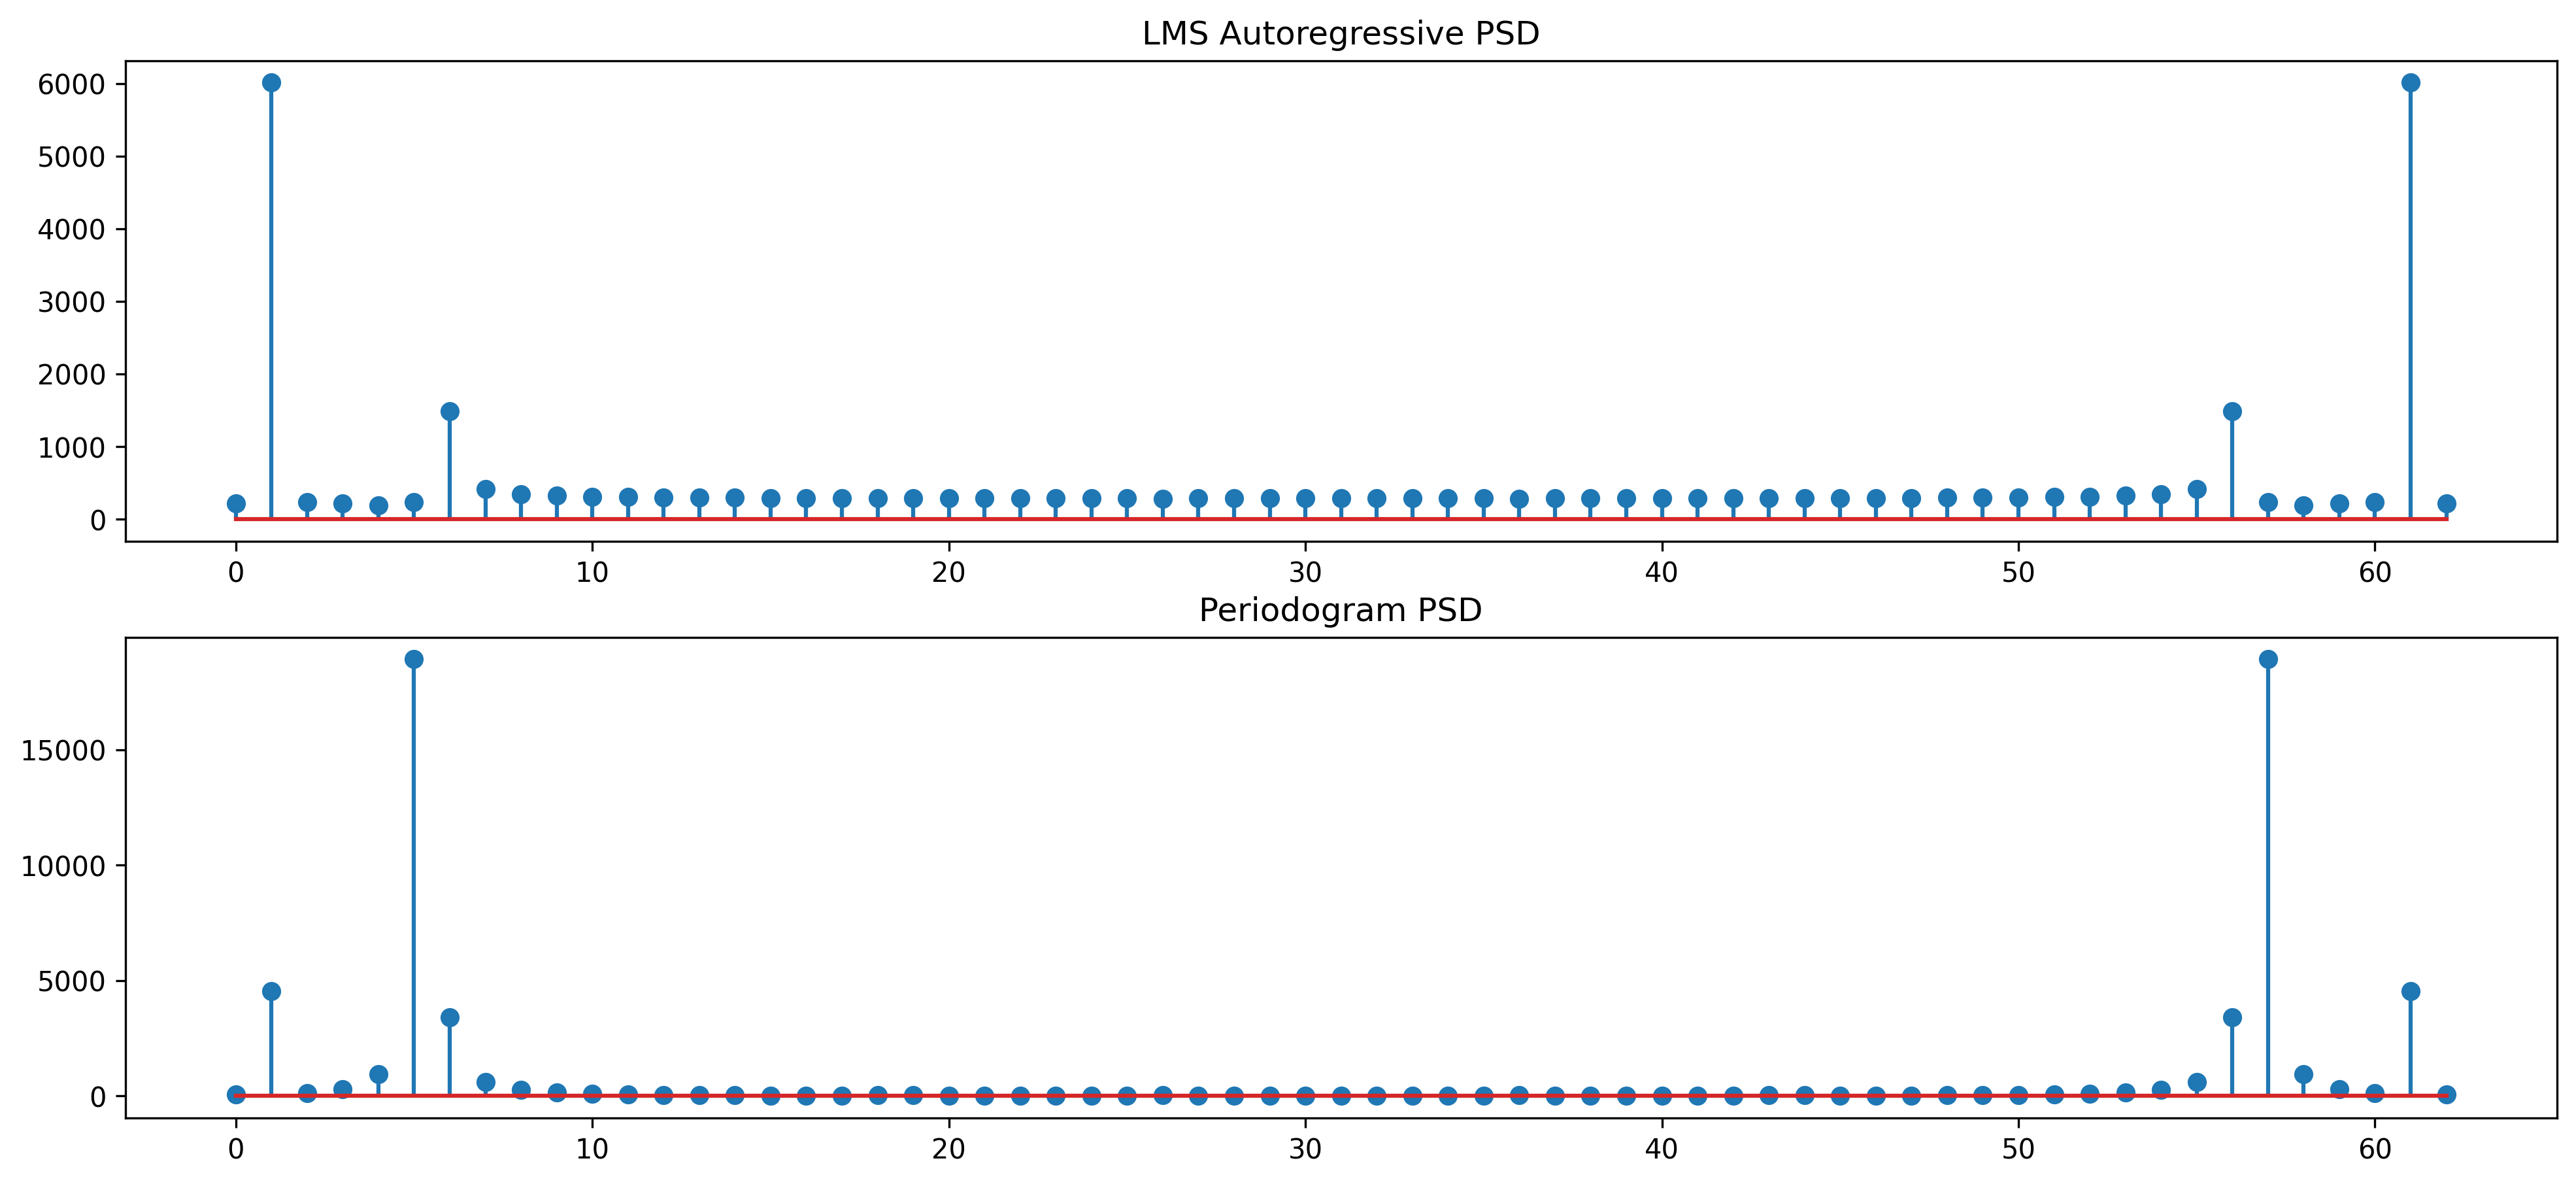

In [103]:
ar_est_c = ar_est_lms(mu, p, x)
P_AR = T*rho/(np.abs(1 + np.fft.fft(ar_est_c)))**2

fig = plt.figure()
fig.set_size_inches(16,7)
fig.set_dpi(300)
plt.subplot(211)
plt.title("LMS Autoregressive PSD")
plt.stem(P_AR[1:])
plt.subplot(212)
plt.title("Periodogram PSD")
plt.stem(fft_x[1:])
plt.show()